In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_4

data = "dream_cytof"
filename = "evaluate_all_figure4"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_4
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

Something's wrong - RMSE values are identical across model variants of the same type (unless they contain mutations).
- I have checked the evaluate_all files of previous figures, and there was never an instance of a repeated RMSE value.
- I have also checked the simulations (e.g., MCF7, val) for three models of the same type (logobs, logobs with baselines, logobs with growth factors) -- we get the same identical simulations -> hence the same identical RMSE values. What is going on??? If we compare it with logobs with mutations, then simulations are clearly different. How can the simulations be identical in this case? Is it that the growth factors and the baselines are missing OR not used for validation cell-lines?

In [3]:
assert all(train_df[train_df.model == "EGFR_MAPK__logobs"].rmse.values == train_df[train_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1"].rmse.values)
assert all(train_df[train_df.model == "EGFR_MAPK__logobs"].rmse.values == train_df[train_df.model == "EGFR_MAPK__logobs_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)
assert all(train_df[train_df.model == "EGFR_MAPK__logobs"].rmse.values == train_df[train_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)

In [4]:
assert all(val_df[val_df.model == "EGFR_MAPK__logobs"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1"].rmse.values)
assert all(val_df[val_df.model == "EGFR_MAPK__logobs"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)
assert all(val_df[val_df.model == "EGFR_MAPK__logobs"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)

In [5]:
assert all(train_df[train_df.model == "EGFR_MAPK__logobs_mbraf_mkras"].rmse.values == train_df[train_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2_mbraf_mkras"].rmse.values)

In [6]:
assert all(val_df[val_df.model == "EGFR_MAPK__logobs_mbraf_mkras"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2_mbraf_mkras"].rmse.values)

In [7]:
assert all(val_df[val_df.model == "EGFR_MAPK__logobs_tegfr"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_begfr_berbb2_bmek_brps6ka1"].rmse.values)
assert all(val_df[val_df.model == "EGFR_MAPK__logobs_tegfr"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)
assert all(val_df[val_df.model == "EGFR_MAPK__logobs_tegfr"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2"].rmse.values)

In [8]:
assert all(val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_mbraf_mkras"].rmse.values == val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2_mbraf_mkras"].rmse.values)

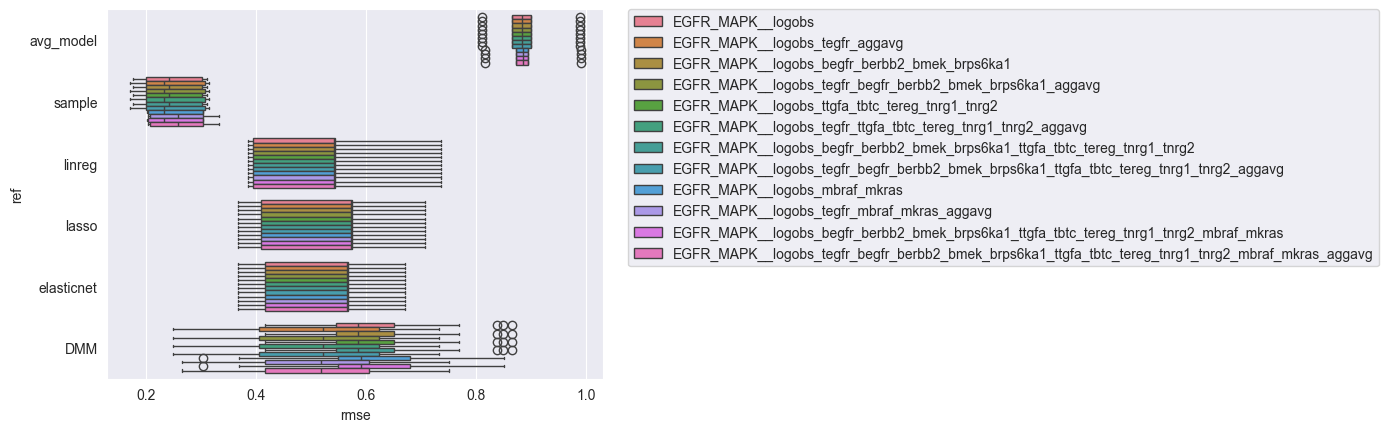

In [9]:
sns.boxplot(
    val_df,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

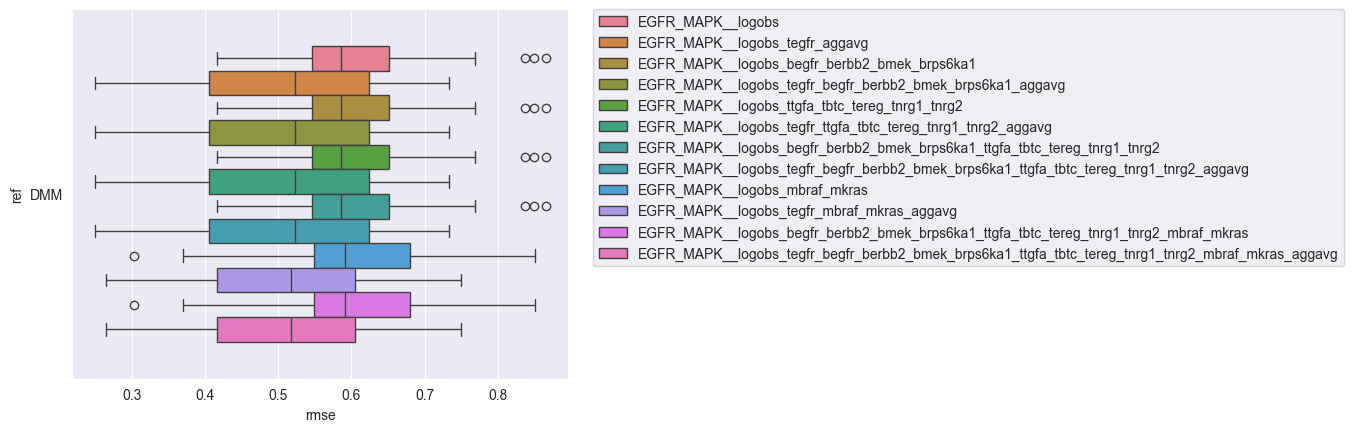

In [10]:
sns.boxplot(
    val_df[val_df.ref == "DMM"],
    y="ref",
    x="rmse",
    hue="model",
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [11]:
val_df.groupby(["ref", "model"]).rmse.mean()

ref     model                                                                                             
DMM     EGFR_MAPK__logobs                                                                                     0.601801
        EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1                                                          0.601801
        EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2                             0.601801
        EGFR_MAPK__logobs_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2_mbraf_mkras                 0.598809
        EGFR_MAPK__logobs_mbraf_mkras                                                                         0.598809
                                                                                                                ...   
sample  EGFR_MAPK__logobs_tegfr_begfr_berbb2_bmek_brps6ka1_ttgfa_tbtc_tereg_tnrg1_tnrg2_aggavg                0.244588
        EGFR_MAPK__logobs_tegfr_begfr_berbb2_bmek_brps6ka1_t